# Electrograms from local activation times

This tutorial approximates electrograms (EGMs) from a local activation time (LAT) map, one action-potential (AP) template, and a spatial sensitivity field for each electrode. The simulation supplies the LAT map and template; the EGM calculation then uses spatial gradients, weighted time bins, and a convolution without constructing a voltage movie for every tissue point.

The use of activation-shifted AP templates follows the modeling approach discussed by [Pezzuto et al. (2017)](https://doi.org/10.3389/fphys.2017.00265). The electrode sensitivity formulation is motivated by the lead-field treatment in [Potse (2018)](https://doi.org/10.3389/fphys.2018.00370). The derivation and binning scheme below explain this notebook's simplified implementation, rather than reproducing a complete bidomain or torso model from either paper.

## 1. Generate a LAT map and an AP template

The example uses a 256 × 256 grid with `dr = 0.2` mm, the Fenton–Karma model, and a central circular region with conductivity set to 0.3 instead of 1.0. A corner stimulus initiates propagation. `ActivationTimeTracker` records the first sampled crossing above 0.5, while `ActionPotentialTracker` records the AP at `[10, 10]`.

The integration step is 0.01 ms and both trackers run every 10 steps, giving a nominal sample interval of 0.1 ms. The AP derivative and the EGM time bins must use the AP sampling interval, not the integration step. This example assumes every included cell has activated and that the LAT map is finite and spatially meaningful.

Running FentonKarma on (256, 256) Grid: 100%|██████████| 30000/30000 [00:04<00:00, 6423.10it/s]


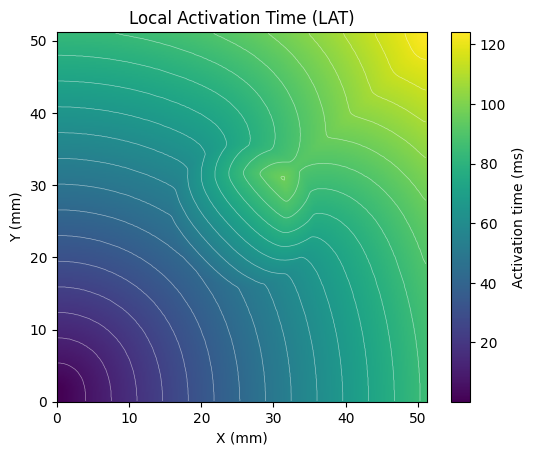

In [1]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import finitewave as fw

grid_size = 256
dr = 0.2

dist_map = np.zeros((grid_size, grid_size))
dist_map[grid_size // 2, grid_size // 2] = 1.0
dist_map = ndimage.distance_transform_edt(1 - dist_map)
mask = dist_map < 50

tissue = fw.CardiacTissue(shape=(grid_size, grid_size), dr=dr)
tissue.conductivity = np.ones((grid_size, grid_size))
tissue.conductivity[mask] = 0.3

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1.0,
                                           x_min=0, x_max=10,
                                           y_min=0, y_max=2))

act_pot_tracker = fw.ActionPotentialTracker([10, 10], step=10)
lat_tracker = fw.ActivationTimeTracker(threshold=0.5, step=10)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(lat_tracker)
tracker_sequence.add_tracker(act_pot_tracker)

simulation = fw.CardiacSimulation(dt=0.01, t_max=300, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.FentonKarma()
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

simulation.run()

lats = lat_tracker.output

plt.figure()
plt.imshow(lats, cmap="viridis", origin="lower",
           extent=[0, grid_size * dr, 0, grid_size * dr])
plt.colorbar(label="Activation time (ms)")
plt.contour(lats, origin="lower", levels=20, colors="white", linewidths=0.5, alpha=0.5,
            extent=[0, grid_size * dr, 0, grid_size * dr])
plt.title("Local Activation Time (LAT)")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

## 2. Prepare the AP template

Let $A(s)$ be the recorded action potential and $a$ its activation time on the template clock. Assuming the same AP shape at every tissue point, the local activation time $\tau(\mathbf{x})$ determines its temporal shift:

$$
V_m(\mathbf{x},t)=A\bigl(t-\tau(\mathbf{x})+a\bigr).
$$

Here $a$ is the activation time within the recorded AP template (`act_time`), taken by default at the maximum upstroke slope; it aligns the template activation with the local LAT.

Define the AP derivative relative to activation as

$$
g(u)=A'(u+a).
$$

Applying the chain rule gives

$$
\nabla V_m(\mathbf{x},t)
=-A'\bigl(t-\tau(\mathbf{x})+a\bigr)\nabla\tau(\mathbf{x})
=-g\bigl(t-\tau(\mathbf{x})\bigr)\nabla\tau(\mathbf{x}).
$$

This separates the temporal AP waveform from the spatial activation pattern, allowing the EGM calculation to combine one AP derivative with the LAT map. The example retains the first 6 ms of the template to focus on depolarization; the template activation time and the LAT map should use the same activation criterion for consistent alignment.


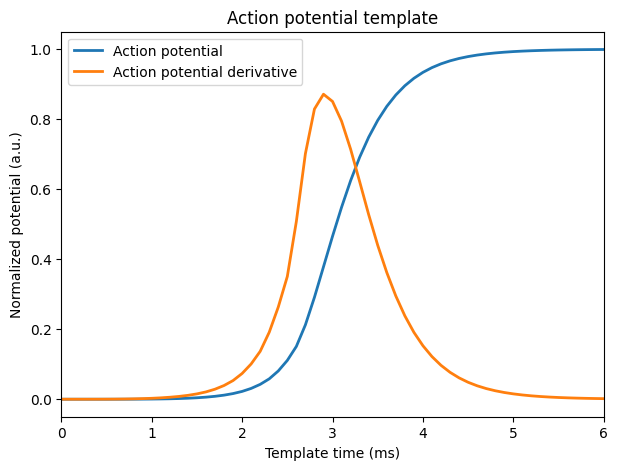

In [2]:
def compute_ap_derivative(v_ap, dt=0.1, act_time=None, upstroke_window=None):
    """Compute the time derivative of an action potential (AP) template.

    Parameters
    ----------
    v_ap : array_like
        Action potential template, sampled at uniform time intervals.
    dt : float, optional
        Time step between samples in v_ap (default: 0.1 ms).
    act_time : float, optional
        Activation time on the template clock (ms); defaults to maximum upstroke slope.
    upstroke_window : tuple of float, optional
        Absolute template-time window (start, end) in ms to restrict the derivative calculation
        to the upstroke phase of the AP (default: None, which uses the entire AP).

    Returns
    -------
    dvdt : ndarray
        Time derivative of the action potential, restricted to the upstroke window if specified.
    act_time : float
        Activation time on the template clock (ms).
    end_time : float
        Retained sample count times dt (ms), not the last absolute sample time.
    """
    v_ap = np.asarray(v_ap, dtype=float)
    dvdt = np.gradient(v_ap, dt)
    ap_times = np.arange(len(v_ap)) * dt

    if act_time is None:
        act_time = np.argmax(dvdt) * dt

    if upstroke_window is not None:
        start, end = upstroke_window

        if start < 0 or end > ap_times[-1]:
            raise ValueError("Upstroke window is out of bounds of the action potential template.")
        
        if start > act_time or end < act_time:
            raise ValueError("Upstroke window does not include the activation time.")

        keep = (ap_times >= start) & (ap_times <= end)

        if not np.any(keep):
            raise ValueError("Upstroke window does not overlap the template.")
        
        dvdt = dvdt[keep]

    end_time = len(dvdt) * dt
    
    return dvdt, act_time, end_time


times = act_pot_tracker.tracking_times
act_pot = act_pot_tracker.output
upstroke_window = [0, 6]  # ms
dvdt, act_time, end_time = compute_ap_derivative(act_pot, dt=0.1, upstroke_window=[0, 6])

dvdt_times = upstroke_window[0] + np.arange(len(dvdt)) * 0.1

plt.figure(figsize=(7, 5))
plt.plot(times, act_pot, lw=2, label="Action potential")
plt.plot(dvdt_times, dvdt, lw=2, label="Action potential derivative")
plt.title("Action potential template")
plt.ylabel("Normalized potential (a.u.)")
plt.xlabel("Template time (ms)")
plt.xlim(0, 6)
plt.legend()
plt.show()

## 3. Define the electrode sensitivity

`compute_lead_field` evaluates the inverse-distance field for each point electrode above the tissue sheet, including the extracellular conductivity prefactor:

$$
Z_m(x,y)=\frac{1}{4\pi\sigma_e\sqrt{(x-x_m)^2+(y-y_m)^2+h_m^2}}.
$$

The input `electrode_coords` contains `(row, col, height)` in grid units, either as one coordinate triple or an array of shape `(M, 3)`. The function converts all coordinate differences to millimeters using `dr` and returns flattened `lead_fields` with shape `(M, P)`, where `P` is the product of the grid dimensions. A positive electrode height avoids a singularity on the sheet.

This homogeneous-conductor field is a simplified choice; a lead field incorporating a more detailed volume conductor can replace it (see the [Lead Field Electrograms tutorial](<Lead Field Electrograms.ipynb>)). The extracellular conductivity factor is now included, but intracellular source conductivity, sheet thickness, and AP voltage calibration are still needed for physically calibrated EGM amplitudes.


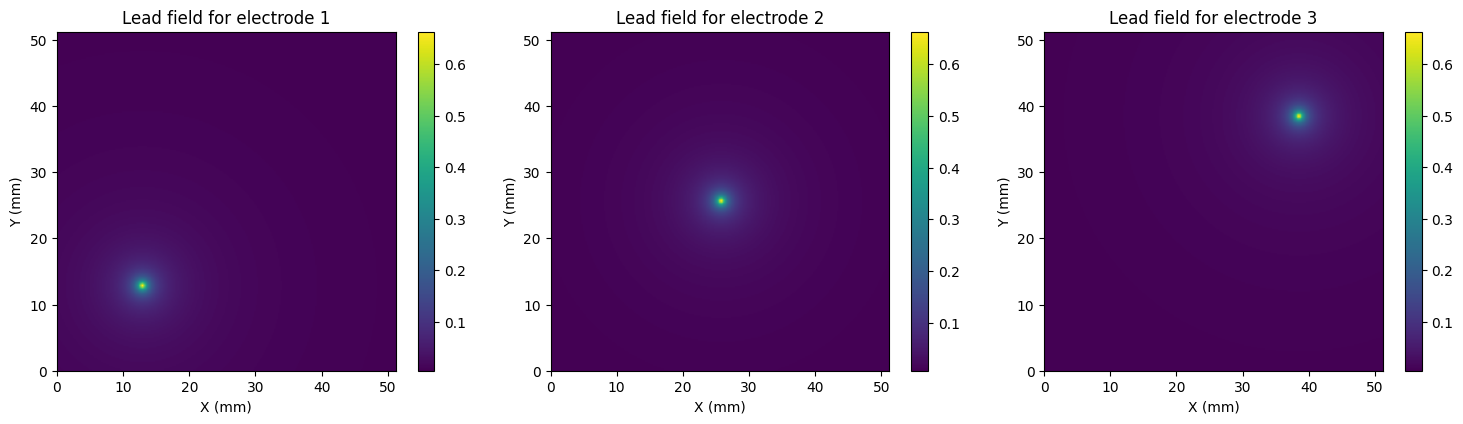

In [3]:

def compute_lead_field(electrode_coords, shape, dr, sigma_extracellular=0.3):
    """Compute the lead field as an inverse distance function on a 2D or 3D grid.

    Parameters
    ----------
    electrode_coords : array_like, shape (3,) or (M, 3)
        Electrode coordinates in grid units, ordered by mesh axis.
        For a 2D grid, the third coordinate is height above the sheet.
    shape : tuple of int
        Grid shape.
    dr : float
        Grid spacing in mm.
    sigma_extracellular : float, optional
        Extracellular conductivity in mS/mm (default: 0.3).

    Returns
    -------
    lead_field : ndarray, shape (M, P)
        Lead fields in flattened grid order, P is the size of the grid.
        Values have units of inverse mS for the specified input units.
    """
    electrode_coords = np.atleast_2d(electrode_coords)

    if len(shape) == 2:
        shape = (shape[0], shape[1], 1)

    x, y, z = np.indices(shape)
    coords = np.stack((x.ravel(), y.ravel(), z.ravel()), axis=-1)

    distance = dr * np.linalg.norm(coords[None, :, :] - 
                                   electrode_coords[:, None, :], axis=-1)

    coeff = 1 / (4 * np.pi * sigma_extracellular)
    lead_field = coeff / distance
    
    return lead_field


height_offset = 2
electrode_coords = [(0.25 * grid_size, 0.25 * grid_size, height_offset),
                    (0.50 * grid_size, 0.50 * grid_size, height_offset),
                    (0.75 * grid_size, 0.75 * grid_size, height_offset)]

lead_fields = compute_lead_field(electrode_coords, lats.shape, dr=dr)

fig, axs = plt.subplots(1, len(electrode_coords), figsize=(15, 4))
for i, ax in enumerate(axs):
    im = ax.imshow(lead_fields[i].reshape(lats.shape),
                   cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Lead field for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 4. Form the spatial source weights

Adopt the electrode polarity convention

$$
E_m(t)=-C\int_\Omega \nabla Z_m\cdot\boldsymbol{\sigma}_i\nabla V_m\,d\Omega,
$$

Here $Z_m$ already includes the extracellular conductivity prefactor, while $C$ can account for the sheet thickness or other remaining scale factors; do not apply the extracellular prefactor twice. Reversing the lead polarity reverses the sign. Substituting the shifted-template identity yields

$$
E_m(t)=C\int_\Omega
\left(\nabla Z_m\cdot\boldsymbol{\sigma}_i\nabla\tau\right)
 g(t-\tau)\,d\Omega.
$$

This is the tutorial's specialization of a gradient-based lead-field formulation ([Potse, 2018](https://doi.org/10.3389/fphys.2018.00370)). For the implemented scalar unit-intracellular-conductivity sheet approximation, define

$$
q_{m,p}=dr^2\sum_{k=0}^{1}(\partial_k Z_m)_p(\partial_k\tau)_p,
\qquad
E_m(t)\approx\sum_p q_{m,p}\,g(t-\tau_p).
$$

The arrays below describe the calculation, with `P = Ny * Nx` tissue points, `M = 3` electrodes, `L` retained AP derivative samples, and `T` returned EGM samples:

| Quantity | Shape | Meaning |
|---|---|---|
| `lats` | `(Ny, Nx)` | Activation times |
| `electrode_coords` | `(M, 3)` | Electrode row, column, and height in grid units |
| `act_pot` | `(N_ap,)` | Recorded AP template |
| `times` | `(N_ap,)` | AP recording times (ms) |
| `dvdt` | `(L,)` | Retained AP derivative |
| `dvdt_times` | `(L,)` | Retained derivative sample times (ms) |
| `lead_fields` | `(M, P)` | Flattened electrode fields |
| `lat_grad` | `(2, P)` | Spatial LAT derivatives |
| `lead_field_grads` | `(M, 2, P)` | Spatial lead-field derivatives |
| `source_weights` | `(M, P)` | Each tissue point's contribution to each electrode, area-scaled before convolution |
| `time_ms` | `(T,)` | Returned EGM times (ms) |
| `egms` | `(M, T)` | EGM traces for all electrodes |

The three contribution maps show where tissue contributes to each electrode signal. Multiplication by the cell area `dr**2` converts these spatial contributions into the weights used for the EGM calculation.

The simulation's heterogeneous conductivity affects the LAT map, but is not explicitly multiplied into the EGM source weights in this implementation. Including a scalar conductivity map or a tensor requires the corresponding factor or tensor contraction in $q_{m,p}$.

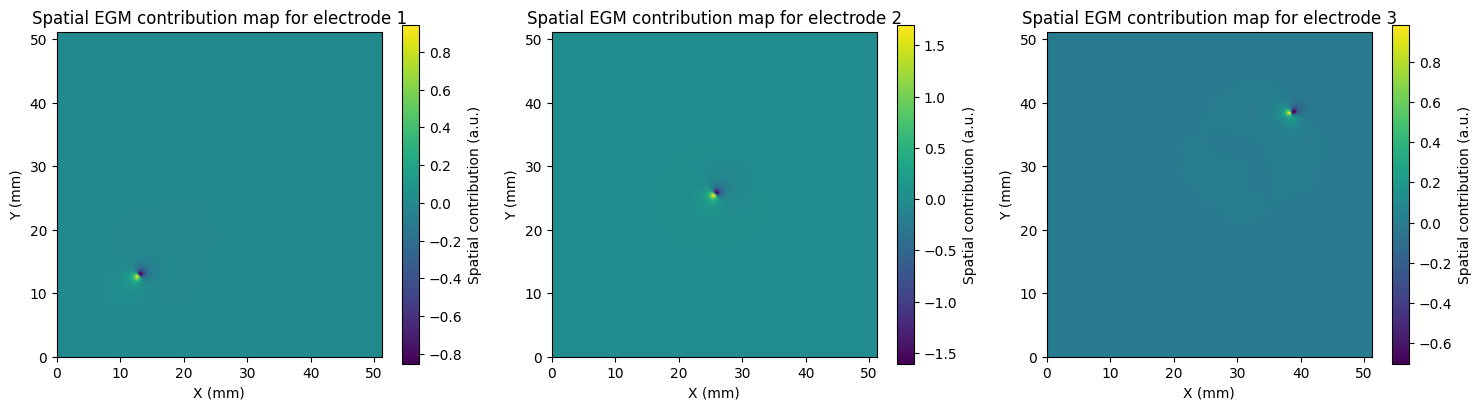

In [5]:
def compute_gradients(grad_ops, x):
    """Compute spatial gradients using a gradient operator.

    Parameters
    ----------
    grad_ops : sequence of sparse matrices
        One (P, P) derivative operator per spatial axis.
    x : ndarray
        One scalar field containing P values in the operators' node ordering.

    Returns
    -------
    grad : ndarray
        Spatial derivatives shaped (ndim, P), ordered by mesh axis.
        No area factor is applied.
    """
    x = np.asarray(x, dtype=float)
    x = x.ravel()

    grads = np.stack([g @ x for g in grad_ops], axis=0)

    return grads

spatial_discretization = fw.FiniteDifferenceGradient()
grad_ops = spatial_discretization.build_gradient_operator(tissue.mesh, dr=dr)

lead_field_grads = np.array([compute_gradients(grad_ops, lead_field) for lead_field in lead_fields])
lat_grad = compute_gradients(grad_ops, lats)

source_weights = np.sum((lat_grad[None, ...] * lead_field_grads), axis=1)

fig, axs = plt.subplots(1, len(electrode_coords), figsize=(15, 4))
for i, ax in enumerate(axs):
    source_weight_map = source_weights[i].reshape(lats.shape)
    im = ax.imshow(source_weight_map, cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Spatial EGM contribution map for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax, label="Spatial contribution (a.u.)")
plt.tight_layout()
plt.show()


## 5. Calculate electrograms

For each electrode, the spatial source weights are accumulated into activation-time bins, splitting each contribution between neighboring bins to preserve fractional LAT timing. The resulting weighted activation sequence is convolved with the AP derivative to obtain the EGM, and the returned signal is restricted to the interval between the earliest and latest LAT.


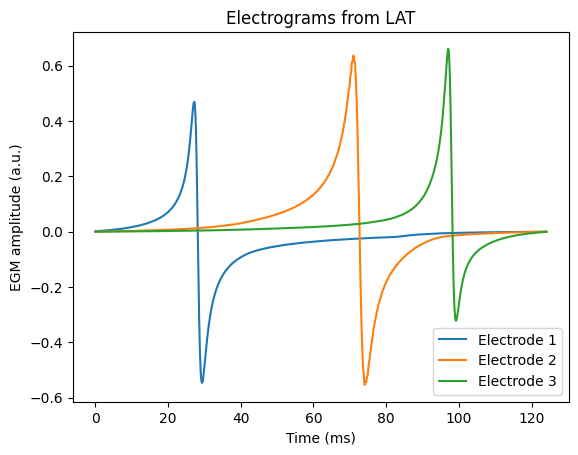

In [6]:
import numpy as np


def convolve_with_template(lat, source_weights, dvdt, act_time, end_time, dr, dt):
    """Calculate EGMs from LAT, spatial source weights, and an AP derivative.

    Parameters
    ----------
    lat : ndarray
        LAT values (ms), flattened internally to P points.
    source_weights : array_like, shape (M, P)
        Spatial dot products in the same point order as lat, already
        multiplied by the cell area dr**2 for this 2D example.
    dvdt : array_like
        Time derivative of the action potential, sampled at uniform time intervals.
    act_time : float
        Activation time on the AP template clock (ms).
    end_time : float
        Retained derivative sample count times dt (ms), used for time alignment.
    dr : float
        Grid spacing (mm); retained in the interface but unused here.
        Apply spatial integration factors when forming source_weights.
    dt : float
        Time step between samples in dvdt (ms).
    
    Returns
    -------
    time_ms : ndarray
        Time points corresponding to the EGM samples (ms).
    egm : ndarray
        Calculated electrograms, shaped (num_electrodes, num_time_points).

    """
    lat_min = lat.min()
    lat_max = lat.max()
    position = ((lat - lat_min) / dt).ravel()
    left = np.floor(position).astype(int)
    fraction = position - left
    n_bins = int(left.max()) + 2

    signals = []
    for electrode_weights in source_weights:
        w = electrode_weights.ravel()

        histogram = np.bincount(left, weights=w * (1 - fraction), minlength=n_bins)
        histogram += np.bincount(left + 1, weights=w * fraction, minlength=n_bins)

        signals.append(np.convolve(histogram, dvdt, mode="full"))

    egm = np.stack(signals)
    right_overlap_time = end_time - act_time
    times = lat_min - right_overlap_time + np.arange(egm.shape[1]) * dt
    mask = (times >= lat_min) & (times <= lat_max)
    time_ms = times[mask]
    egm = egm[:, mask]
    return time_ms, egm


lat_grad = compute_gradients(grad_ops, lats)
source_weights = np.sum(lat_grad[None, ...] * lead_field_grads, axis=1) * dr ** 2

dvdt, act_time, end_time = compute_ap_derivative(act_pot, dt=0.1, upstroke_window=[0, 6])
time_ms, egms = convolve_with_template(lats, source_weights, dvdt, act_time, end_time, dr=dr, dt=0.1)

plt.figure()
for electrode_index, egm in enumerate(egms):
    plt.plot(time_ms, egm, label=f"Electrode {electrode_index + 1}")
plt.title("Electrograms from LAT")
plt.xlabel("Time (ms)")
plt.ylabel("EGM amplitude (a.u.)")
plt.legend()
plt.show()

## References

1. Pezzuto S., Kal'avský P., Potse M., Prinzen F. W., Auricchio A., and Krause R. (2017). [Evaluation of a Rapid Anisotropic Model for ECG Simulation](https://doi.org/10.3389/fphys.2017.00265). *Frontiers in Physiology*, **8**, 265. Background on activation times, shifted AP templates, and lead-field ECG calculation.
2. Potse M. (2018). [Scalable and Accurate ECG Simulation for Reaction-Diffusion Models of the Human Heart](https://doi.org/10.3389/fphys.2018.00370). *Frontiers in Physiology*, **9**, 370. Lead-field formulation and precomputation of electrode-dependent quantities.